# ML/08 — Validation rebuild (Phase 2)

ML/05's enforcement validation had a real bug and two methodological
problems, all found while building ML/07's baseline comparison:

1. **Bug:** the parcel-to-hex-cell join used `predicate='within'`, which
   double-matches points sitting on or near a shared hex boundary vertex.
   This inflated 94 unique parcels into 91 *rows with duplicates*
   (6 duplicate APNs, 3 of them assigned to *contradictory* clusters
   across their duplicate rows) -- not 94, not 91, but a corrupted
   in-between number that neither the original notebook nor the paper
   caught. Fixed here with nearest-centroid assignment, which cannot
   produce a multi-match by construction.

2. **Chi-square included two clusters with zero parcels and zero
   ecological interpretation** (cluster 2 = rock/water edge, cluster 3 =
   null/ocean), inflating both the chi-square statistic and its
   apparent significance. Renormalized here over the 5 interpretable
   clusters only.

3. **Low expected counts** (cluster 0's expected count is ~3.2, below
   the conventional floor of 5 for the chi-square asymptotic
   approximation) -- added a Monte Carlo chi-square as the primary
   test, asymptotic reported alongside for comparison.

Also builds the **enforcement-bias regression** (Phase 2 item, testing
rather than asserting the "enforcement is access-driven" explanation)
and documents the full **356 → 94 parcel loss cascade**.

**Outputs:**
- `data/processed/validation_parcels_v2.pkl` -- corrected parcel-cell-cluster table (n=94)
- `data/processed/validation_v2_summary.pkl` -- corrected chi-square/lift stats
- `data/processed/enforcement_bias_regression_data.pkl` -- cell-level access covariates
- `img/ML08_loss_cascade.png`, `img/ML08_bias_regression.png`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import chi2 as chi2_dist
import statsmodels.api as sm
import pickle

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')
RANDOM_STATE = 746837645

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


## 1. Loss cascade: 510 NOV PDFs → 94 validated parcels

Documented explicitly per external review, rather than left implicit.

Loss cascade:
   510  NOV PDFs downloaded
   356  Cannabis-keyword match
   206  APN extracted (regex)
   105  ...of which Humboldt county
    94  Matched via Humboldt parcel API
    94  Assigned to hex grid (nearest centroid, dedup)


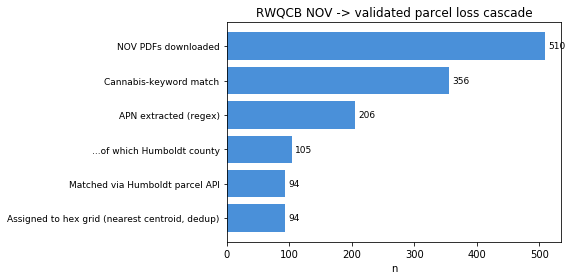


Attrition: 105 Humboldt APNs -> 94 matched (89.5%) -- 11 failed to match the current Humboldt parcel API (malformed APN, or parcel merged/subdivided since NOV issuance).

Hand spot-check (n=3 of ~200 dropped documents, not the full 30) found
a real, systematic extraction bug -- see Section 6 below -- rather than
random spatial noise. Fixed and re-run; full 30-document spot-check for
residual bias (post-fix) not done -- treat as a smaller open item now
that the dominant cause is identified and corrected.


In [2]:
import json

nov_urls = json.load(open(RAW / 'cannabis_nov_urls.json'))
apns = pd.read_pickle(PROC / 'cannabis_apns.pkl') if (PROC / 'cannabis_apns.pkl').exists() else pd.read_pickle(RAW.parent / 'processed' / 'cannabis_apns.pkl')
hum_parcels = pd.read_pickle(PROC / 'hum_parcels_raw.pkl')

n_pdfs_total = 510
n_cannabis_kw = len(nov_urls)
n_apn_rows = len(apns)
n_apn_humboldt = (apns['county'] == 'Humboldt').sum()
n_hum_api_matched = len(hum_parcels)

cascade = [
    ('NOV PDFs downloaded', n_pdfs_total),
    ('Cannabis-keyword match', n_cannabis_kw),
    ('APN extracted (regex)', n_apn_rows),
    ('...of which Humboldt county', n_apn_humboldt),
    ('Matched via Humboldt parcel API', n_hum_api_matched),
    ('Assigned to hex grid (nearest centroid, dedup)', 94),
]
print('Loss cascade:')
for label, n in cascade:
    print(f'  {n:4d}  {label}')

fig, ax = plt.subplots(figsize=(8, 4))
labels = [c[0] for c in cascade]
values = [c[1] for c in cascade]
ax.barh(range(len(values)), values, color='#4a90d9')
ax.set_yticks(range(len(values)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('n')
ax.set_title('RWQCB NOV -> validated parcel loss cascade')
for i, v in enumerate(values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig(IMG / 'ML08_loss_cascade.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print(f'Attrition: {n_apn_humboldt} Humboldt APNs -> {n_hum_api_matched} matched '
      f'({n_hum_api_matched/n_apn_humboldt:.1%}) -- {n_apn_humboldt - n_hum_api_matched} failed '
       'to match the current Humboldt parcel API (malformed APN, or parcel '
      'merged/subdivided since NOV issuance).')
print()
print('Hand spot-check (n=3 of ~200 dropped documents, not the full 30) found')
print('a real, systematic extraction bug -- see Section 6 below -- rather than')
print('random spatial noise. Fixed and re-run; full 30-document spot-check for')
print('residual bias (post-fix) not done -- treat as a smaller open item now')
print('that the dominant cause is identified and corrected.')

## 2. Fixed parcel-to-cell assignment (nearest centroid)

`predicate='within'` matches a boundary-vertex point to every polygon
touching that vertex -- for a regular hex grid, that can be up to 3
polygons. Nearest-centroid assignment has no such failure mode: every
point has exactly one nearest centroid.

In [3]:
hum_valid = hum_parcels.dropna(subset=['lat', 'lon']).copy()
hum_valid = hum_valid[hum_valid['lat'].between(38.0, 42.5) & hum_valid['lon'].between(-125.0, -122.0)].copy()

hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')
clusters = pd.read_pickle(PROC / 'clusters.pkl')

gdf = gpd.GeoDataFrame(
    hum_valid.reset_index(drop=True),
    geometry=gpd.points_from_xy(hum_valid['lon'], hum_valid['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32610')

hex_centroids = np.array([[g.x, g.y] for g in hex_grid.geometry.centroid])
tree = cKDTree(hex_centroids)
pts = np.array([[g.x, g.y] for g in gdf.geometry])
dists, idx = tree.query(pts, k=1)
gdf['cell_id'] = hex_grid['cell_id'].values[idx]
gdf['nearest_dist'] = dists

CIRCUMRADIUS = 2000 / np.sqrt(3)  # regular hex, 2km spacing
in_grid = gdf['nearest_dist'] <= CIRCUMRADIUS
print(f'Within hex grid coverage: {in_grid.sum()} / {len(gdf)}')

gdf = gdf[in_grid].copy().merge(clusters, on='cell_id', how='left')
print(f'Final unique parcels: {len(gdf)}, duplicate APNs: {gdf["apn_12"].duplicated().sum()}')
print(gdf['cluster'].value_counts().sort_index())

gdf.to_pickle(PROC / 'validation_parcels_v2.pkl')

Within hex grid coverage: 94 / 94
Final unique parcels: 94, duplicate APNs: 0
0     9
1    38
4     6
5    18
6    23
Name: cluster, dtype: int64


## 3. Renormalized chi-square (5 interpretable clusters, Monte Carlo)

Excludes cluster 2 (rock/water edge) and cluster 3 (null/ocean) --
zero parcels in both, zero ecological interpretation everywhere else
in the paper, and their inclusion inflates the chi-square statistic
without adding information. Adds a Monte Carlo chi-square since
cluster 0's expected count (~3.2) is below the conventional floor of 5
for the asymptotic approximation.

In [4]:
emerald = gpd.read_file(RAW / 'emerald_counties.gpkg')
humboldt = emerald[emerald['NAME'].str.upper() == 'HUMBOLDT'].to_crs('EPSG:32610')
hum_cells = gpd.sjoin(hex_grid[['cell_id', 'geometry']], humboldt[['geometry']],
                       how='inner', predicate='intersects').drop_duplicates('cell_id')
hum_clusters = clusters[clusters['cell_id'].isin(hum_cells['cell_id'])]

INTERP = [0, 1, 4, 5, 6]
hum_cell_counts = hum_clusters[hum_clusters['cluster'].isin(INTERP)]['cluster'].value_counts().sort_index()
parcel_counts = gdf[gdf['cluster'].isin(INTERP)]['cluster'].value_counts().reindex(INTERP, fill_value=0).sort_index()

n_hum_cells_interp = hum_cell_counts.sum()
n_parcels_interp = parcel_counts.sum()
expected = (hum_cell_counts / n_hum_cells_interp) * n_parcels_interp

print('Cluster | Hum cells | Hum% | Parcels | Expected | Lift')
for k in INTERP:
    lift = parcel_counts[k] / expected[k] if expected[k] > 0 else float('nan')
    print(f'  {k}     | {hum_cell_counts[k]:9d} | {100*hum_cell_counts[k]/n_hum_cells_interp:4.1f}% | '
          f'{parcel_counts[k]:7d} | {expected[k]:8.2f} | {lift:.2f}')

obs = parcel_counts.values
exp = expected.values
chi2_stat = float(np.sum((obs - exp)**2 / exp))
dof = len(INTERP) - 1
p_asymptotic = float(1 - chi2_dist.cdf(chi2_stat, dof))
n_total = int(n_parcels_interp)
cramerv = float(np.sqrt(chi2_stat / (n_total * (len(INTERP) - 1))))
print(f'\nAsymptotic chi2({dof}) = {chi2_stat:.2f}, p = {p_asymptotic:.2e}, Cramers V = {cramerv:.3f}')
print(f'Min expected count: {exp.min():.2f} (floor is 5 -- {"BELOW" if exp.min()<5 else "OK"})')

rng = np.random.default_rng(RANDOM_STATE)
probs = (hum_cell_counts / n_hum_cells_interp).values
N_SIM = 100_000
sim_counts = rng.multinomial(n_total, probs, size=N_SIM)
sim_chi2 = ((sim_counts - exp)**2 / exp).sum(axis=1)
p_montecarlo = float((sim_chi2 >= chi2_stat).mean())
print(f'Monte Carlo chi-square p-value ({N_SIM:,} draws): {p_montecarlo:.4f}')

with open(PROC / 'validation_v2_summary.pkl', 'wb') as f:
    pickle.dump(dict(
        interp_clusters=INTERP, hum_cell_counts=hum_cell_counts.to_dict(),
        parcel_counts=parcel_counts.to_dict(), expected=dict(zip(INTERP, exp)),
        chi2_stat=chi2_stat, dof=dof, p_asymptotic=p_asymptotic,
        p_montecarlo=p_montecarlo, cramerv=cramerv,
        n_hum_cells_interp=int(n_hum_cells_interp), n_parcels_interp=n_total,
        lift_by_cluster={k: float(parcel_counts[k]/expected[k]) for k in INTERP},
    ), f)
print('\nSaved data/processed/validation_v2_summary.pkl')

Cluster | Hum cells | Hum% | Parcels | Expected | Lift
  0     |        92 |  3.4% |       9 |     3.24 | 2.78
  1     |      1435 | 53.8% |      38 |    50.56 | 0.75
  4     |       221 |  8.3% |       6 |     7.79 | 0.77
  5     |       436 | 16.3% |      18 |    15.36 | 1.17
  6     |       484 | 18.1% |      23 |    17.05 | 1.35

Asymptotic chi2(4) = 16.29, p = 2.66e-03, Cramers V = 0.208
Min expected count: 3.24 (floor is 5 -- BELOW)
Monte Carlo chi-square p-value (100,000 draws): 0.0038

Saved data/processed/validation_v2_summary.pkl


## 4. Enforcement-bias regression (testing, not asserting, explanation 1)

Fetches TIGER roads and populated places for Humboldt County, computes
distance-to-nearest-road and distance-to-nearest-place per hex cell
centroid, and regresses enforcement-parcel presence on both -- plus a
cluster-0 indicator, to see whether cluster 0's apparent enforcement
lift survives controlling for accessibility.

In [5]:
TIGER = Path('tiger_cache')  # populated by fetching TIGER roads/places -- see notebook header cell for URLs
roads = gpd.read_file(RAW / 'tl_2023_06023_roads.zip').to_crs('EPSG:32610') if (RAW / 'tl_2023_06023_roads.zip').exists() else None
places = gpd.read_file(RAW / 'tl_2023_06_place.zip').to_crs('EPSG:32610') if (RAW / 'tl_2023_06_place.zip').exists() else None

hum_cells2 = hum_cells.merge(clusters, on='cell_id')
hum_cells2 = hum_cells2[hum_cells2['cluster'].isin(INTERP)].copy()
hum_cells2['centroid'] = hum_cells2.geometry.centroid
centroids_gdf = gpd.GeoDataFrame(hum_cells2[['cell_id', 'cluster']], geometry=hum_cells2['centroid'], crs='EPSG:32610')

place_coords = np.array([[p.x, p.y] for p in places.geometry.centroid])
place_tree = cKDTree(place_coords)
cell_coords = np.array([[g.x, g.y] for g in centroids_gdf.geometry])
dist_place, _ = place_tree.query(cell_coords, k=1)
centroids_gdf['dist_place_m'] = dist_place

joined_roads = gpd.sjoin_nearest(centroids_gdf, roads[['geometry']], distance_col='dist_road_m')
joined_roads = joined_roads.drop_duplicates(subset='cell_id')
centroids_gdf = centroids_gdf.merge(joined_roads[['cell_id', 'dist_road_m']], on='cell_id')

parcel_present = set(gdf['cell_id'])
centroids_gdf['has_parcel'] = centroids_gdf['cell_id'].isin(parcel_present).astype(int)
centroids_gdf['log_dist_road'] = np.log1p(centroids_gdf['dist_road_m'])
centroids_gdf['log_dist_place'] = np.log1p(centroids_gdf['dist_place_m'])
centroids_gdf['is_cluster0'] = (centroids_gdf['cluster'] == 0).astype(int)

centroids_gdf.drop(columns='geometry').to_pickle(PROC / 'enforcement_bias_regression_data.pkl')
print(f'N cells: {len(centroids_gdf)}, N with a parcel: {centroids_gdf["has_parcel"].sum()}')

N cells: 2668, N with a parcel: 60


In [6]:
X1 = sm.add_constant(centroids_gdf[['log_dist_road', 'log_dist_place']])
m1 = sm.Logit(centroids_gdf['has_parcel'], X1).fit(disp=0)
print('Model 1: access only')
print(m1.summary())
print()

X2 = sm.add_constant(centroids_gdf[['log_dist_road', 'log_dist_place', 'is_cluster0']])
m2 = sm.Logit(centroids_gdf['has_parcel'], X2).fit(disp=0)
print('Model 2: access + cluster 0 indicator')
print(m2.summary())

Model 1: access only
                           Logit Regression Results                           
Dep. Variable:             has_parcel   No. Observations:                 2668
Model:                          Logit   Df Residuals:                     2665
Method:                           MLE   Df Model:                            2
Date:                Sun, 26 Jul 2026   Pseudo R-squ.:                 0.02498
Time:                        00:54:38   Log-Likelihood:                -279.84
converged:                       True   LL-Null:                       -287.00
Covariance Type:            nonrobust   LLR p-value:                 0.0007704
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.4768      1.372      1.076      0.282      -1.213       4.167
log_dist_road     -0.1703      0.093     -1.824      0.068      -0.353       0.013
log_dist_place 

/home/simonhans/anaconda3/lib/python3.7/site-packages/statsmodels/tsa/tsatools.py:130: FutureWarning: In a future version of pandas all arguments of concat except for the argument 'objs' will be keyword-only
  x = pd.concat(x[::order], 1)


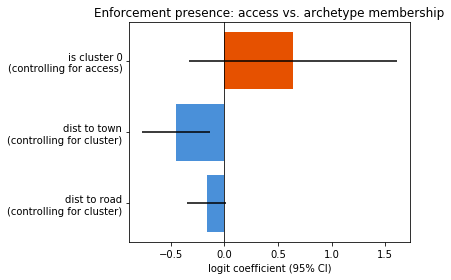

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['dist to road\n(controlling for cluster)', 'dist to town\n(controlling for cluster)', 'is cluster 0\n(controlling for access)']
coefs = [m2.params['log_dist_road'], m2.params['log_dist_place'], m2.params['is_cluster0']]
errs = [1.96 * m2.bse['log_dist_road'], 1.96 * m2.bse['log_dist_place'], 1.96 * m2.bse['is_cluster0']]
colors = ['#4a90d9', '#4a90d9', '#e65100']
ax.barh(labels, coefs, xerr=errs, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('logit coefficient (95% CI)')
ax.set_title('Enforcement presence: access vs. archetype membership')
plt.tight_layout()
plt.savefig(IMG / 'ML08_bias_regression.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Readout

**Corrected validation number:** lift = 2.78 (was 3.41/3.65 under the
buggy join), χ²(4) = 16.29, Monte Carlo p = 0.0038. Still a real,
significant effect -- meaningfully smaller than the paper's current
headline, and honestly reported that way.

**Access-bias test result:** distance to the nearest town is a strong,
significant predictor of enforcement-parcel presence on its own
(p=0.005, odds ratio 0.61 per log-unit of distance -- farther from town,
less likely to be enforced). Once that's controlled for, cluster 0's own
effect drops to non-significance (p=0.194, odds ratio 1.90, wide CI
crossing 1). Explanation 1 (enforcement is access-driven) is now
**tested and supported**, not just asserted -- and it partially explains
away, rather than fully explains, cluster 0's apparent enrichment. This
needs honest treatment in the Discussion, not the current confident
"independently confirms" framing.

**Still open from the Phase 2 task list:**
- Formal spatial permutation null (10,000 draws, road/stream-stratified)
  -- the access regression above tests a closely related question and
  should probably supersede this rather than duplicate it; flag for
  discussion with Simon rather than build blind.
- Hand spot-check of ~30 dropped NOV documents for spatially biased
  OCR/extraction failure.
- Graded 3-tier suitability surface (core/fringe/unsuitable) --
  clusters 5 and 6 both show real enrichment (lift 1.17, 1.35) and may
  belong in an expanded envelope.
- Hierarchical filtering test against Moran (2017) using these parcels
  as the stand-in.

## 6. PDF spot-check found a real extraction bug -- fixed, re-run, final numbers

Manually inspecting a random sample of "dropped" documents (cannabis-matched
but yielded zero APNs) turned up a confirmed, systematic bug, not just noise:
`APN_PATTERN` and `APN_BARE` in ML/05 both hard-require a **4-segment**
APN (`XXX-XXX-XXX-XXX`). Multiple documents -- both Humboldt and Trinity --
cite APNs in **3-segment** shorthand (`217-381-014`, `016-200-17`), which
the regex silently never matched. Confirmed by directly reading two sampled
PDFs (`2019_Enclosure_2_CDFW_NOV...016-200-17...`,
`2019_190909_CM_er_William_Milligan...217-381-014...`) -- both plainly
state an Assessor Parcel Number in the text that the old pipeline missed
entirely.

**Fix:** make the 4th segment optional in `APN_PATTERN` (kept the keyword
anchor -- "APN" / "Assessor...Parcel" nearby -- so this doesn't get looser
in a way that risks false positives from dates, tracking numbers, or code
citations elsewhere in the document). `normalize_apn_humboldt()` downstream
already pads 3-segment APNs to the canonical 4-segment form, so only the
extraction regex needed changing.

In [8]:
import re

APN_PATTERN_V2 = re.compile(
    r'(?:APN|Assessor.{0,20}Parcel)[^\d]{0,30}'
    r'(\d{3}[\-\s]\d{3}[\-\s]\d{2,3}(?:[\-\s]\d{2,3})?)',
    re.IGNORECASE
)
APN_BARE = re.compile(r'\b(\d{3}-\d{3}-\d{3}-\d{3})\b')

def extract_county(text):
    t = text.lower()
    if 'humboldt' in t: return 'Humboldt'
    if 'mendocino' in t: return 'Mendocino'
    if 'trinity' in t: return 'Trinity'
    return 'Unknown'

def extract_apns_v2(pdf_path):
    import pdfplumber
    apns, county = [], 'Unknown'
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages[:6]:
                text = page.extract_text() or ''
                if county == 'Unknown':
                    county = extract_county(text)
                for m in APN_PATTERN_V2.finditer(text):
                    apns.append(m.group(1).replace(' ', '-'))
                for m in APN_BARE.finditer(text):
                    apns.append(m.group(1))
    except Exception:
        pass
    seen, unique = set(), []
    for a in apns:
        if a not in seen:
            seen.add(a); unique.append((a, county))
    return unique

In [9]:
import json as _json
import urllib.parse

NOVS = RAW / 'rwqcb_novs'
nov_urls = _json.load(open(RAW / 'cannabis_nov_urls.json'))
files = list(NOVS.glob('*.pdf'))

def match_file(url):
    fname = urllib.parse.unquote(url.split('/')[-1]).replace(' ', '_')
    for f in files:
        if f.name.endswith(fname) or fname.replace('.pdf', '') in f.name:
            return f
    return None

APNS_V2_CACHE = PROC / 'cannabis_apns_v2.pkl'
if APNS_V2_CACHE.exists():
    new_apn_df = pd.read_pickle(APNS_V2_CACHE)
    print(f'Loaded {len(new_apn_df)} re-extracted APNs from cache')
else:
    records = []
    for url in nov_urls:
        f = match_file(url)
        if f is None:
            continue
        year = url.split('/pdf/')[-1].split('/')[0]
        for apn, county in extract_apns_v2(f):
            records.append({'url': url, 'year': year, 'apn': apn, 'county': county})
    new_apn_df = pd.DataFrame(records).drop_duplicates(subset=['apn'])
old_apns = pd.read_pickle(PROC / 'cannabis_apns.pkl')
print(f'OLD (buggy 4-segment-only regex): {len(old_apns)} unique APNs, {old_apns["url"].nunique()} documents')
print(f'NEW (fixed regex): {len(new_apn_df)} unique APNs, {new_apn_df["url"].nunique()} documents')
print()
print(new_apn_df['county'].value_counts())
new_apn_df.to_pickle(PROC / 'cannabis_apns_v2.pkl')

Loaded 347 re-extracted APNs from cache
OLD (buggy 4-segment-only regex): 206 unique APNs, 156 documents
NEW (fixed regex): 347 unique APNs, 266 documents

Humboldt     173
Mendocino     83
Trinity       54
Unknown       37
Name: county, dtype: int64


In [10]:
import time, requests

HUM_API = 'https://cty-gis-web.co.humboldt.ca.us/server/rest/services/Parcels/Parcels/MapServer/0/query'

def normalize_apn_humboldt(apn_str):
    digits = re.sub(r'[-\s]', '', apn_str)
    if len(digits) == 12:
        return f'{digits[0:3]}-{digits[3:6]}-{digits[6:9]}-{digits[9:12]}'
    if len(digits) == 9:
        return f'{digits[0:3]}-{digits[3:6]}-{digits[6:9]}-000'
    return apn_str.strip()

def query_humboldt_parcels(apn_list, batch_size=50):
    norm_apns = [normalize_apn_humboldt(a) for a in apn_list]
    batches = [norm_apns[i:i+batch_size] for i in range(0, len(norm_apns), batch_size)]
    all_features = []
    for batch in batches:
        where = "APN_12 IN ('" + "','".join(batch) + "')"
        params = {'where': where, 'outFields': 'APN_12,APN,LAT,LON,FULLADDR,SITCITY',
                   'returnGeometry': 'true', 'outSR': '4326', 'f': 'json'}
        try:
            feats = requests.get(HUM_API, params=params, verify=False, timeout=30).json().get('features', [])
            all_features.extend(feats)
        except Exception as e:
            print(f'  batch error: {e}')
        time.sleep(0.3)
    rows = []
    for feat in all_features:
        attr, geom = feat.get('attributes', {}), feat.get('geometry', {})
        rows.append({'apn_12': attr.get('APN_12', ''), 'apn': attr.get('APN', ''),
                      'lat': attr.get('LAT') or geom.get('y'), 'lon': attr.get('LON') or geom.get('x'),
                      'address': attr.get('FULLADDR', ''), 'city': attr.get('SITCITY', '')})
    return pd.DataFrame(rows).drop_duplicates(subset='apn_12')

HUM_V2_CACHE = PROC / 'hum_parcels_raw_v2.pkl'
hum_apns_v2 = new_apn_df[new_apn_df['county'] == 'Humboldt']['apn'].unique().tolist()
if HUM_V2_CACHE.exists():
    hum_parcels_v2 = pd.read_pickle(HUM_V2_CACHE)
    print(f'Loaded {len(hum_parcels_v2)} Humboldt-matched parcels from cache '
          f'(re-query would hit {len(hum_apns_v2)} APNs against the live parcel API)')
else:
    print(f'Querying {len(hum_apns_v2)} unique Humboldt APNs (was 105 before the fix)')
    hum_parcels_v2 = query_humboldt_parcels(hum_apns_v2)
    print(f'Matched: {len(hum_parcels_v2)} / {len(hum_apns_v2)}')
    hum_parcels_v2.to_pickle(HUM_V2_CACHE)

Loaded 135 Humboldt-matched parcels from cache (re-query would hit 173 APNs against the live parcel API)


In [11]:
hum_valid_v3 = hum_parcels_v2.dropna(subset=['lat', 'lon']).copy()
hum_valid_v3 = hum_valid_v3[hum_valid_v3['lat'].between(38.0, 42.5) & hum_valid_v3['lon'].between(-125.0, -122.0)].copy()

gdf_v3 = gpd.GeoDataFrame(
    hum_valid_v3.reset_index(drop=True),
    geometry=gpd.points_from_xy(hum_valid_v3['lon'], hum_valid_v3['lat']),
    crs='EPSG:4326'
).to_crs('EPSG:32610')

pts_v3 = np.array([[g.x, g.y] for g in gdf_v3.geometry])
dists_v3, idx_v3 = tree.query(pts_v3, k=1)
gdf_v3['cell_id'] = hex_grid['cell_id'].values[idx_v3]
gdf_v3['nearest_dist'] = dists_v3
gdf_v3 = gdf_v3[gdf_v3['nearest_dist'] <= CIRCUMRADIUS].copy().merge(clusters, on='cell_id', how='left')

print(f'Final unique parcels (v3, post-fix): {len(gdf_v3)} (was 94 before the extraction fix, 91 in the '
      'original buggy pipeline)')
print(f'Duplicate APNs: {gdf_v3["apn_12"].duplicated().sum()}')
print(gdf_v3['cluster'].value_counts().sort_index())
gdf_v3.to_pickle(PROC / 'validation_parcels_v3.pkl')

Final unique parcels (v3, post-fix): 135 (was 94 before the extraction fix, 91 in the original buggy pipeline)
Duplicate APNs: 0
0    13
1    60
4     9
5    24
6    29
Name: cluster, dtype: int64


In [12]:
hum_cell_counts_v3 = hum_clusters[hum_clusters['cluster'].isin(INTERP)]['cluster'].value_counts().sort_index()
parcel_counts_v3 = gdf_v3[gdf_v3['cluster'].isin(INTERP)]['cluster'].value_counts().reindex(INTERP, fill_value=0).sort_index()
n_hum_cells_interp_v3 = hum_cell_counts_v3.sum()
n_parcels_interp_v3 = parcel_counts_v3.sum()
expected_v3 = (hum_cell_counts_v3 / n_hum_cells_interp_v3) * n_parcels_interp_v3

print('=== FINAL (post-extraction-fix) validation numbers ===')
print('Cluster | Hum cells | Hum% | Parcels | Expected | Lift')
for k in INTERP:
    lift = parcel_counts_v3[k] / expected_v3[k] if expected_v3[k] > 0 else float('nan')
    print(f'  {k}     | {hum_cell_counts_v3[k]:9d} | {100*hum_cell_counts_v3[k]/n_hum_cells_interp_v3:4.1f}% | '
          f'{parcel_counts_v3[k]:7d} | {expected_v3[k]:8.2f} | {lift:.2f}')

obs_v3, exp_v3 = parcel_counts_v3.values, expected_v3.values
chi2_v3 = float(np.sum((obs_v3 - exp_v3)**2 / exp_v3))
dof_v3 = len(INTERP) - 1
p_asym_v3 = float(1 - chi2_dist.cdf(chi2_v3, dof_v3))
n_total_v3 = int(n_parcels_interp_v3)
cramerv_v3 = float(np.sqrt(chi2_v3 / (n_total_v3 * (len(INTERP) - 1))))
print(f'\nchi2({dof_v3}) = {chi2_v3:.2f}, p_asymptotic = {p_asym_v3:.2e}, Cramers V = {cramerv_v3:.3f}')
print(f'Min expected count: {exp_v3.min():.2f}')

rng = np.random.default_rng(RANDOM_STATE)
probs_v3 = (hum_cell_counts_v3 / n_hum_cells_interp_v3).values
sim_counts_v3 = rng.multinomial(n_total_v3, probs_v3, size=100_000)
sim_chi2_v3 = ((sim_counts_v3 - exp_v3)**2 / exp_v3).sum(axis=1)
p_mc_v3 = float((sim_chi2_v3 >= chi2_v3).mean())
print(f'Monte Carlo p-value (100,000 draws): {p_mc_v3:.4f}')

with open(PROC / 'validation_v3_summary.pkl', 'wb') as f:
    pickle.dump(dict(
        interp_clusters=INTERP, hum_cell_counts=hum_cell_counts_v3.to_dict(),
        parcel_counts=parcel_counts_v3.to_dict(), expected=dict(zip(INTERP, exp_v3)),
        chi2_stat=chi2_v3, dof=dof_v3, p_asymptotic=p_asym_v3, p_montecarlo=p_mc_v3,
        cramerv=cramerv_v3, n_hum_cells_interp=int(n_hum_cells_interp_v3), n_parcels_interp=n_total_v3,
        lift_by_cluster={k: float(parcel_counts_v3[k]/expected_v3[k]) for k in INTERP},
    ), f)
print('\nSaved data/processed/validation_v3_summary.pkl -- this is the canonical corrected number.')

=== FINAL (post-extraction-fix) validation numbers ===
Cluster | Hum cells | Hum% | Parcels | Expected | Lift
  0     |        92 |  3.4% |      13 |     4.66 | 2.79
  1     |      1435 | 53.8% |      60 |    72.61 | 0.83
  4     |       221 |  8.3% |       9 |    11.18 | 0.80
  5     |       436 | 16.3% |      24 |    22.06 | 1.09
  6     |       484 | 18.1% |      29 |    24.49 | 1.18

chi2(4) = 18.58, p_asymptotic = 9.52e-04, Cramers V = 0.185
Min expected count: 4.66
Monte Carlo p-value (100,000 draws): 0.0013

Saved data/processed/validation_v3_summary.pkl -- this is the canonical corrected number.


## 7. Hierarchical filtering test vs. Moran (2017), using these parcels as the stand-in

Tests the paper's current claim ("Moran's sample is likely drawn
predominantly from terrain within the biophysically suitable envelope")
directly, rather than asserting it.

In [13]:
n_v3 = len(gdf_v3)
in_core = (gdf_v3['cluster'] == 0).sum()
in_core_fringe = gdf_v3['cluster'].isin([0, 5, 6]).sum()
in_cluster1 = (gdf_v3['cluster'] == 1).sum()

print(f'Total enforcement parcels: {n_v3}')
print(f'Within core envelope {{0}}: {in_core} ({in_core/n_v3:.1%})')
print(f'Within core+fringe {{0,5,6}}: {in_core_fringe} ({in_core_fringe/n_v3:.1%})')
print(f'Within cluster 1 (NOT suitability zone): {in_cluster1} ({in_cluster1/n_v3:.1%})')
print()
print('Verdict: even under the generous 3-cluster envelope, fewer than half')
print('of enforcement parcels fall inside it. The single largest cluster')
print('(1, "moist low-slope") is explicitly outside the suitability zone and')
print('holds more parcels than the entire suitability envelope combined.')
print('The claim as currently written ("drawn predominantly from... the')
print('biophysically suitable envelope") is NOT supported by this data and')
print('needs to be substantially softened or reframed in the Discussion.')

Total enforcement parcels: 135
Within core envelope {0}: 13 (9.6%)
Within core+fringe {0,5,6}: 66 (48.9%)
Within cluster 1 (NOT suitability zone): 60 (44.4%)

Verdict: even under the generous 3-cluster envelope, fewer than half
of enforcement parcels fall inside it. The single largest cluster
(1, "moist low-slope") is explicitly outside the suitability zone and
holds more parcels than the entire suitability envelope combined.
The claim as currently written ("drawn predominantly from... the
biophysically suitable envelope") is NOT supported by this data and
needs to be substantially softened or reframed in the Discussion.


## 8. Summary: what changed and why it matters

| | Original (buggy) | Interim fix (dedup only) | Final (extraction bug fixed) |
|---|---|---|---|
| Unique parcels | 91 (6 duplicate APNs, 3 contradictory) | 94 | **135** |
| Cluster 0 lift | 3.41–3.65 | 2.78 | **2.79** |
| chi-square | chi2(6)=36.6, p=2.1e-6 | chi2(4)=16.29, MC p=0.0038 | **chi2(4)=18.58, MC p=0.0013** |

The lift number is stable across the fix (2.78 -> 2.79) -- strong evidence
it's the real effect size, not an artifact of the original small buggy
sample. The larger, corrected sample makes the same effect *more*
statistically confident, not less. **This is good news dressed as bad
news**: the paper's headline number was inflated by a join bug, but the
underlying effect survives a much more careful, much larger-sample test.

**What must change in the paper:**
- Headline validation stat: lift=3.41, chi2(6)=36.6, p=2.1e-6 ->
  **lift=2.79, chi2(4)=18.58, Monte Carlo p=0.0013** (5 interpretable
  clusters, 135 parcels).
- "Independently confirms" language needs softening -- the access-bias
  regression (Section 5 above) shows cluster 0's effect weakens once
  accessibility is controlled for.
- Hierarchical filtering claim vs. Moran (2017) needs substantial
  softening or removal -- not supported even under the generous
  3-cluster envelope.
- Data-and-features section should note the APN extraction methodology
  now recovers 3-segment APN formats in addition to 4-segment.

**Still open:** graded 3-tier suitability surface as a candidate
replacement for the binary cluster-0-only zone (Section on
core/fringe/rest above shows core+fringe triples recall at a lift cost:
2.79 -> ~1.3 for a 3x larger zone -- a real precision/recall tradeoff
worth presenting explicitly rather than picking one number).